# Emprestimos UFRN

Neste projeto, exploramos os dados de empréstimos dos acervos do sistema de bibliotecas da UFRN entre 2010 e 2020.

Enunciado 
    
    Um dos objetivos de uma biblioteca é garantir que os materiais informacionais estejam sendo utilizados. Os empréstimos realizados podem ser um indicador, mesmo que de forma básica (pois você não consegue garantir que haja uma leitura ou utilização real). Por este motivo, entender a quantidade de empréstimos se torna importante.
    Questões de diferentes perspectivas podem surgir como:

    -   A quantidade de empréstimos está aumentando ou diminuindo ao decorrer dos últimos anos?
    -   Em quais bibliotecas do sistema estão a maior quantidade de empréstimos?
    -   Quais são os temas mais emprestados? E os menos?
    
    Com estas e outras informações será possível entender o cenário e apresentá-lo à diretoria das bibliotecas, para que possam tomar melhores decisões na melhoria da infraestrutura, dos recursos e processos da unidade de informação.

. Classificação do acervo de acordo com a classe de cada assunto:

000 a 099: Generalidades. Ciência e conhecimento.

100 a 199: Filosofia e psicologia.

200 a 299: Religião.

300 a 399: Ciências sociais.

400 a 499: Classe vaga. Provisoriamente não ocupada.

500 a 599: Matemática e ciências naturais.

600 a 699: Ciências aplicadas.

700 a 799: Belas artes.

800 a 899: Linguagem. Língua. Linguística.

900 a 999: Geografia. Biografia. História.




In [1]:
import os
import pandas as pd

## Planilhas de empréstimos

In [2]:
# Loading and concatenating all CSV files of loan registries, "dados_emprestimos"

folder = "Datasets/dados_emprestimos"
csv_files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".csv")])
all_dfs = []
for file in csv_files:
    path = os.path.join(folder, file)
    df = pd.read_csv(path)
    all_dfs.append(df)

emprestimos = pd.concat(all_dfs, ignore_index=True)
emprestimos

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2.008023e+09,ALUNO DE GRADUAÇÃO
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2.008112e+09,ALUNO DE PÓS-GRADUAÇÃO
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,2.007211e+08,ALUNO DE GRADUAÇÃO
4,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO
...,...,...,...,...,...,...,...
2258013,2989086,2008047044,NaN,2020/05/05 19:51:06.059000000,2021/05/13 14:53:31.000000000,3.067431e+06,SERVIDOR TÉCNICO-ADMINISTRATIVO
2258014,2989087,2008047047,NaN,2020/05/05 19:51:06.135000000,2021/05/13 14:53:38.000000000,3.067431e+06,SERVIDOR TÉCNICO-ADMINISTRATIVO
2258015,2989088,2010052905,NaN,2020/05/05 19:51:06.164000000,2021/05/13 15:01:46.000000000,3.067431e+06,SERVIDOR TÉCNICO-ADMINISTRATIVO
2258016,2989089,2010048023,NaN,2020/06/09 11:54:02.669000000,2021/07/21 15:33:55.000000000,2.020101e+10,ALUNO DE PÓS-GRADUAÇÃO


In [6]:
# Cleaning the data

# 0. removing duplicates in the loan dataset
emprestimos = emprestimos.drop_duplicates()

# 1. Checking for missing values in the loan dataset
# print(emprestimos.isnull().sum())

min_date = '1900/01/01 00:00:00.000000'
# min_date = emprestimos['data_renovacao'].dropna().min()
emprestimos['data_renovacao'] = emprestimos['data_renovacao'].fillna(min_date)

# min_date = emprestimos['data_devolucao'].dropna().min()
emprestimos['data_devolucao'] = emprestimos['data_devolucao'].fillna(min_date)

emprestimos['matricula_ou_siape'] = emprestimos['matricula_ou_siape'].fillna("000000000000000")


In [ ]:
# 2. Fixing formats of date columns in the loan dataset

# dates 
emprestimos['data_renovacao'] = pd.to_datetime(emprestimos['data_renovacao'],format="%Y/%m/%d %H:%M:%S.%f")
emprestimos['data_emprestimo'] = pd.to_datetime(emprestimos['data_emprestimo'],format="%Y/%m/%d %H:%M:%S.%f")
emprestimos['data_devolucao'] = pd.to_datetime(emprestimos['data_devolucao'],format="%Y/%m/%d %H:%M:%S.%f")
# matricula
emprestimos['matricula_ou_siape'] = emprestimos['matricula_ou_siape'].astype('str')

# inconsistencies in 'codigo_barras'
# emprestimos['codigo_barras'] = emprestimos['codigo_barras'].str.split('_').str[0]

# emprestimos.dtypes
emprestimos.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario
0,709684,L095049,1900-01-01 00:00:00.000,2010-01-04 07:44:10.721,2010-01-05 16:26:12.662,2008023265.0,ALUNO DE GRADUAÇÃO
1,709685,L167050,1900-01-01 00:00:00.000,2010-01-04 07:44:10.750,2010-01-12 07:34:13.934,2008023265.0,ALUNO DE GRADUAÇÃO
2,709686,2006017618,2010-01-26 08:07:01.738,2010-01-04 08:08:44.081,2010-02-25 07:36:25.800,2008112114.0,ALUNO DE PÓS-GRADUAÇÃO
3,709687,L184117,2010-01-18 11:07:46.470,2010-01-04 08:24:21.284,2010-02-03 08:58:45.692,200721119.0,ALUNO DE GRADUAÇÃO
8,709688,2007027500,2010-01-19 15:59:26.464,2010-01-04 08:27:33.569,2010-02-03 13:06:30.662,2009045971.0,ALUNO DE GRADUAÇÃO


## Acervo

In [ ]:
# Loading Collection data, "dados_exemplares"
file = "Datasets/dados_exemplares.parquet"
acervo = pd.read_parquet(file)

# Fix 'codigo_barras' format - keep only the value before '_'
# acervo['codigo_barras'] = acervo['codigo_barras'].str.split('_').str[0]

# Add a category column based on the numeric part of `localizacao`

def map_categoria(codigo):
    if 0 <= codigo <= 99:
        return "Generalidades. Ciência e conhecimento."
    elif codigo <= 199:
        return "Filosofia e psicologia."
    elif codigo <= 299:
        return "Religião."
    elif codigo <= 399:
        return "Ciências sociais."
    elif codigo <= 499:
        return "Classe vaga. Provisoriamente não ocupada."
    elif codigo <= 599:
        return "Matemática e ciências naturais."
    elif codigo <= 699:
        return "Ciências aplicadas."
    elif codigo <= 799:
        return "Belas artes."
    elif codigo <= 899:
        return "Linguagem. Língua. Linguística."
    elif codigo <= 999:
        return "Geografia. Biografia. História."
    else:
        return "Fora do intervalo"

acervo["categoria"] = acervo["localizacao"].apply(map_categoria)
acervo 


# acervo.duplicated().sum() - checked that there are no duplicated rows in the collection dataset

,id_exemplar,codigo_barras,colecao,biblioteca,status_material,localizacao,registro_sistema,categoria
index,,,,,,,,
0,5,L000003,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,694,1,Ciências aplicadas.
0,4,L000002,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,688,1,Ciências aplicadas.
0,3,L000001,Acervo Circulante,Biblioteca Central Zila Mamede,ESPECIAL,638,1,Ciências aplicadas.
0,7,L000114,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,616,5,Ciências aplicadas.
0,10,L000041,Acervo Circulante,Biblioteca Central Zila Mamede,ESPECIAL,657,15,Ciências aplicadas.
...,...,...,...,...,...,...,...,...
0,1353472,2021011150,Acervo Circulante,Biblioteca Setorial do Núcleo de Educação da I...,REGULAR,951,268231,Geografia. Biografia. História.
0,1353473,2019013454,Acervo Circulante,Biblioteca Central Zila Mamede,ESPECIAL,997,268233,Geografia. Biografia. História.
0,1353474,2019012811,Acervo Circulante,Biblioteca Central Zila Mamede,ESPECIAL,987,268234,Geografia. Biografia. História.


# Nova base - datos limpos e cruzados com dados do acervo

In [22]:
# newbase = pd.merge(emprestimos, acervo.drop(['registro_sistema'], axis=1), on="codigo_barras", how="left")
newbase = emprestimos.merge(acervo)
# newbase.isnull().sum()
# some loans have no match in the collection dataset -- they might have a different code, or they might be loans of items that are not in the collection dataset 
# rows_with_missing = newbase[newbase.isnull().any(axis=1)]
# display(rows_with_missing.head())


## Análise dos dados

A quantidade de empréstimos está aumentando ou diminuindo ao decorrer dos últimos anos?

Quais os meses com maior número de exemplares emprestados? E quais os horários de maior movimento?

Quais os volumes/tema mais requisitados?

Em quais bibliotecas do sistema estão a maior quantidade de empréstimos?

Quais são os temas mais emprestados? E os menos?

In [16]:
# Relaçao entre numero de empréstimos e numero de exemplares (em 1 emprestimo pode haver mais de um exemplar)
nemprest = len(newbase['id_emprestimo'].drop_duplicates())
exemplares = len(newbase)
print(f"Número de empréstimos: {nemprest}")
print(f"Número de exemplares: {exemplares}")

Número de empréstimos: 2068724
Número de exemplares: 2072522


In [ ]:
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt


# Exemplares emprestados por ano

emprestimos_data = pd.DataFrame(newbase['data_emprestimo'].value_counts()).reset_index()
emprestimos_data.columns = ['data', 'quantidade']
emprestimos_data['data'] = pd.to_datetime(emprestimos_data['data'])
emprestimos_data

,data,quantidade
0,2014-01-28 14:49:50.505,3
1,2014-05-12 09:56:18.787,3
2,2014-07-14 15:35:51.822,3
3,2015-05-05 20:37:19.551,3
4,2015-06-02 17:56:18.917,3
...,...,...
2068686,2020-05-05 19:51:06.059,1
2068687,2020-05-05 19:51:06.135,1
2068688,2020-05-05 19:51:06.164,1
2068689,2020-06-09 11:54:02.669,1


In [95]:
emprestimos_por_ano = emprestimos_data.groupby(emprestimos_data.data.dt.year).size().to_frame(name='quantidade')
emprestimos_por_ano.index.name = 'ano'
display(emprestimos_por_ano)

emprestimos_por_mes = emprestimos_data.groupby(emprestimos_data.data.dt.month).size().to_frame(name='quantidade')
emprestimos_por_mes.index.name = 'mes'
display(emprestimos_por_mes)

emprestimos_por_hora = emprestimos_data.groupby(emprestimos_data.data.dt.hour).size().to_frame(name='quantidade')
emprestimos_por_hora.index.name = 'hora'
display(emprestimos_por_hora)


,quantidade
ano,
2010,161277
2011,196199
2012,221141
2013,234431
2014,218765
2015,213117
2016,215411
2017,217974
2018,193547


,quantidade
mes,
1,67391
2,209839
3,251710
4,208339
5,202139
6,137815
7,123588
8,232371
9,207875


,quantidade
hora,
0,17
6,14
7,18735
8,103226
9,131032
10,185457
11,179713
12,148459
13,126756


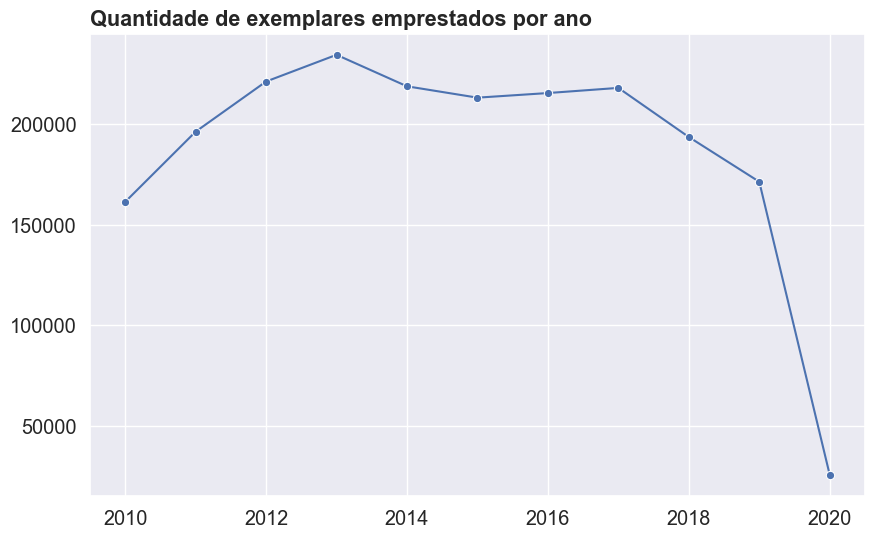

In [93]:
# Graficos

sns.set_theme(context='notebook', 
              style='darkgrid', 
              palette='deep', 
              font_scale=1.3, 
              rc={"figure.figsize":(10,6)})

ax1 = sns.lineplot(data=emprestimos_por_ano, x = 'ano', y = 'quantidade', marker='o')
ax1.set(xlabel = None, ylabel= None)
ax1.set_title('Quantidade de exemplares emprestados por ano',loc='left', fontweight='bold')
plt.show()

- Queda expressiva na quantidade de exemplares emprestados a partir de 2017; 
- O ano de 2020 deve ser desconsiderado para análise pela ocorrência da pandemia, um fator excepcional

A direção da biblioteca pode investigar essa queda:
- uso de acervo digital?
- o acervo está desatualizado?
- o número de alunos da universidade está diminuindo?
- novos alunos são bem introduzidos ao sistema? houve alguma mudança de estratégia de divulgação?
- queda iniciou-se em 2013, e houve um leve aumento em 2017 - houveram fatos relevantes nesses dois anos?

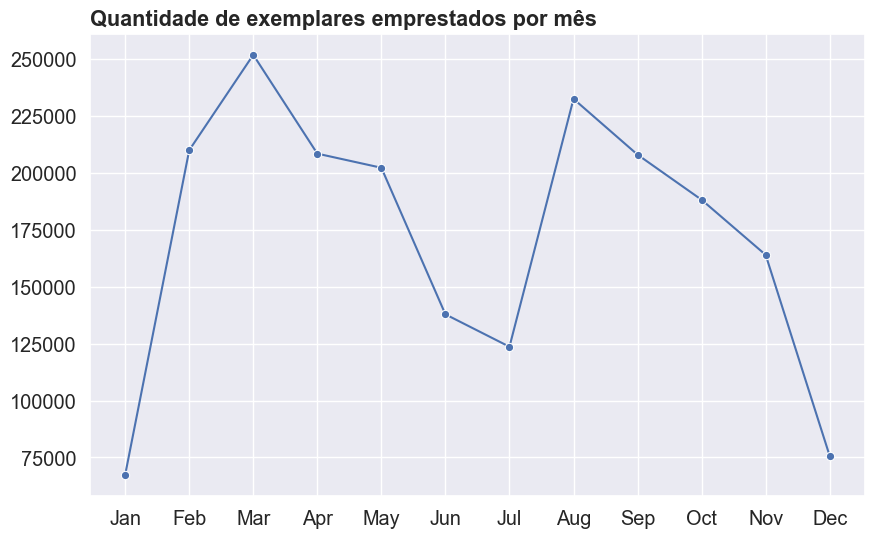

In [94]:
ax2 = sns.lineplot(data=emprestimos_por_mes, x = 'mes', y = 'quantidade', marker='o')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax2.set(xlabel = None, ylabel= None)
ax2.set_title('Quantidade de exemplares emprestados por mês',loc='left', fontweight='bold')
ax2.xaxis.set_major_locator(ticker.FixedLocator(range(1, 13)))
ax2.set_xticklabels(month_names)
plt.show()

Como esperado, o início de cada semestre letivo - Março e Agosto - são os mais movimentados. Janeiro e Dezembro são os meses de menor movimento, acompanhados por Junho e Julho. São, portanto, os meses mais propícios para férias dos funcionários.

Pode-se pensar em alguma estratégia para incentivar os empréstimos nesses meses, como projetos de leitura nas férias e extensão do período de empréstimo.

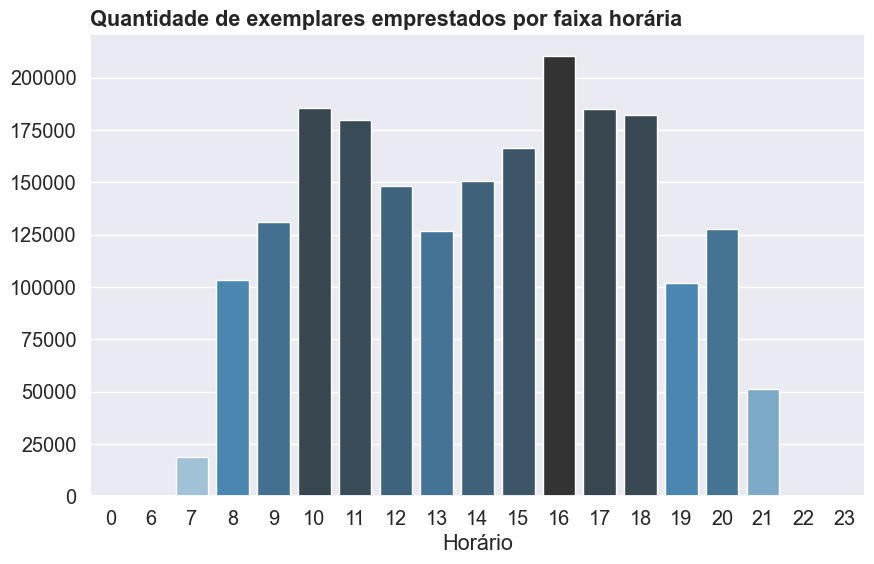

In [99]:
emprestimos_por_hora = emprestimos_por_hora.sort_values(by='quantidade', ascending=True)
ax3 = sns.barplot(data=emprestimos_por_hora, x = 'hora', y = 'quantidade',palette='Blues_d',hue='quantidade')
plt.legend([],[], frameon=False)
ax3.set(xlabel = "Horário", ylabel= None)
ax3.set_title('Quantidade de exemplares emprestados por faixa horária',loc='left', fontweight='bold')
plt.show()

Os horários de picos de empréstimos são às 10h e às 16h (intervalo de aulas). Os horários menos movimentados são no começo e no fim do expediente, entre 7h e 9h e entre 19h e 22h.

In [100]:
temas = [c for c in newbase.columns if 'categoria' in c.lower()]
if not temas:
    raise ValueError('Nenhuma coluna de categoria encontrada em newbase')

tema_col = temas[0]
loan_counts_by_tema = newbase[tema_col].value_counts().sort_values(ascending=False)
loan_counts_by_tema

categoria
Ciências aplicadas.                       1425473
Ciências sociais.                          369536
Matemática e ciências naturais.             68744
Generalidades. Ciência e conhecimento.      62521
Religião.                                   62295
Filosofia e psicologia.                     60563
Geografia. Biografia. História.              7989
Belas artes.                                 7911
Linguagem. Língua. Linguística.              7490
Name: count, dtype: int64

In [101]:
biblioteca_cols = [c for c in newbase.columns if 'biblioteca' in c.lower()]
if not biblioteca_cols:
    raise ValueError('Nenhuma coluna de biblioteca encontrada em newbase')

biblioteca_col = biblioteca_cols[0]
loan_counts_by_biblioteca = newbase[biblioteca_col].value_counts().sort_values(ascending=False)

loan_counts_by_biblioteca

biblioteca
Biblioteca Central Zila Mamede                                                              1426122
Biblioteca Setorial do Centro Ciências da Saúde - CCS                                        118614
Biblioteca Setorial da Faculdade de Ciências da Saúde do Trairi - FACISA - Santa Cruz         77609
Biblioteca Setorial Prof. Alberto Moreira Campos - ­Departamento de Odontologia               66447
Biblioteca Setorial Profª. Maria Lúcia da Costa Bezerra - ­CERES­ - Caicó                     61478
Biblioteca Setorial Bertha Cruz Enders - ­Escola de Saúde da UFRN - ESUFRN                    46040
Biblioteca Setorial do Centro de Ciências Humanas, Letras e Artes - CCHLA                     40744
Biblioteca Setorial Dr. Paulo Bezerra - EMCM/RN - Caicó                                       32097
Biblioteca Setorial Profª. Maria José Mamede Galvão - FELCS - Currais Novos                   29089
Biblioteca Setorial Prof. Rodolfo Helinski - Escola Agrícola de Jundiaí - EAJ  - Macaiba 